Cleaned version of self_rag.ipynb ready for integrating into evaluation.

Changes to the original LangGraph Implementation:
1. Used MarkdownTextSplitter
2. Customized QUESTION_TEMPLATE same as fast_n_slow experiments (question, dtype, default value, and description)
3. Decouple the route and state update logic for hallucination and answer grade
4. Optimize the prompt for RAG chain (w feedback and wo feedback)
5. Add unit (e.g. "Tonnes 000") checking knowledge to Hallucination grader system prompt
6. Integrate into pdf_agent_fast_n_slow.py run
7. Run 1st eval

In [1]:
from typing import Any, List, Optional

import tiktoken
from IPython.display import Image, display
from langchain.text_splitter import MarkdownHeaderTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import END, START, StateGraph
from openai import OpenAI
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from agent_k.config.logger import logger
from agent_k.config.schemas import TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION
from agent_k.utils.general import (
    prompt_openai_assistant,
)

CLIENT = OpenAI()
NUM_RETRIEVED_DOCS = 4
MODEL = "gpt-4o-mini"


def count_tokens(text):
    try:
        encoding = tiktoken.get_encoding("cl100k_base")
        return len(encoding.encode(text))
    except Exception as e:
        logger.warning(f"Error counting tokens: {e}")
        logger.warning("Falling back to rough approximation (4 tokens per character)")
        return len(text) // 4


def create_markdown_retriever(
    markdown_path: str,
    collection_name: str = "rag-chroma",
    headers_to_split_on: Optional[list[tuple[str, str]]] = None,
    embedding_model: str = "text-embedding-3-small",
) -> Chroma:
    """
    Creates a Chroma retriever from a markdown document.

    Args:
        markdown_path: Path to the markdown file
        collection_name: Name for the Chroma collection
        headers_to_split_on: List of tuples containing markdown header levels and their names
        embedding_model: Name of the OpenAI embedding model to use

    Returns:
        Chroma retriever object
    """
    # Set default headers if none provided
    if headers_to_split_on is None:
        headers_to_split_on = [
            ("#", "Header 1"),
            ("##", "Header 2"),
            ("###", "Header 3"),
        ]

    # Read markdown file
    try:
        with open(markdown_path, "r", encoding="utf-8") as file:
            markdown_document = file.read()
    except Exception as e:
        logger.error(f"Error reading markdown file: {e}")
        raise

    # Split document
    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on
    )
    doc_splits = markdown_splitter.split_text(markdown_document)

    # Log splitting information
    try:
        markdown_document_tokens = count_tokens(markdown_document)
        doc_splits_len = len(doc_splits)
        avg_tokens = markdown_document_tokens / doc_splits_len

        logger.info(f"Number of tokens: {markdown_document_tokens}")
        logger.info(f"Number of splits: {doc_splits_len}")
        logger.info(f"Average tokens per split: {avg_tokens:.0f}")
    except Exception as e:
        logger.warning(f"Could not log token statistics: {e}")

    # Create vectorstore and retriever
    try:
        vectorstore = Chroma.from_documents(
            documents=doc_splits,
            collection_name=collection_name,
            embedding=OpenAIEmbeddings(model=embedding_model),
        )

        retriever = vectorstore.as_retriever(search_kwargs={"k": NUM_RETRIEVED_DOCS})
        return retriever
    except Exception as e:
        logger.error(f"Error creating retriever: {e}")
        raise


# Example usage:
# retriever = create_markdown_retriever(
#     "data/processed/43-101/02a2b93ee61f2863bcb417b27855cb63d63a3c53b73622174f7c5688b0d4dc159c.md",
#     collection_name="rag-chroma"
# )

# results = retriever.invoke("What's the mineral site name?")
# results

In [2]:
### Retrieval Grader


class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    reasoning: str = Field(
        description="Reasoning why the document is relevant to the question or not"
    )
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

QUESTION_TEMPLATE = """**Question:** What's the {field} of the mineral site in the attached 43-101 report?
**Data type of {field}:** {dtype}
**Default value of {field} if not found:** {default}
**Description of {field}:** {description}"""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

In [3]:
### Generate

# Deep Extraction Assistant
DEEP_EXTRACT_SYSTEM_PROMPT = """You are an advanced AI assistant that answers questions based on the attached NI 43-101 mineral report. Your responses should be grounded in the report's content using the code interpreter tool for numerical calculations if needed.

## Response Workflow:
1. Perform Aggregations (If Needed): Use the code interpreter tool for operations like summation, averaging, or other calculations.
2. Structure the Response Correctly: Format your final output with XML tags as follows:
    - Reasoning: Explain your retrieval or computation process within `<thinking>` tags.
    - Final Answer: Provide the final response within `<output>` tags. Do not include other extra XML tags (e.g., `<answer>`) or filler words.

## Key Constraints:
- No Hallucination: If the required information is unavailable, return the default value specified in the JSON schema in the `<output>` tag.
"""

GENERATION_USER_PROMPT_WO_FEEDBACK = """You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just return the default value of the field in the question.

{question}
**Context:** {context} 
---
Now take a deep breath and answer the question step by step."""

GENERATION_USER_PROMPT_W_FEEDBACK = """You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just return the default value of the field in the question.

{question}
**Context:** {context} 
**Previous Incorrect Answer:** {previous_generation}
**Feedback on why the previous answer is incorrect:** {hallucination_grader_reasoning}
---
Now take a deep breath and answer the question step by step while considering the feedback."""


prompt_wo_feedback = ChatPromptTemplate.from_messages(
    [
        ("system", DEEP_EXTRACT_SYSTEM_PROMPT),
        ("human", GENERATION_USER_PROMPT_WO_FEEDBACK),
    ]
)

prompt_w_feedback = ChatPromptTemplate.from_messages(
    [
        ("system", DEEP_EXTRACT_SYSTEM_PROMPT),
        ("human", GENERATION_USER_PROMPT_W_FEEDBACK),
    ]
)

# LLM
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0.1)


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain_wo_feedback = prompt_wo_feedback | llm | StrOutputParser()
rag_chain_w_feedback = prompt_w_feedback | llm | StrOutputParser()


### Alternative RAG chain using OpenAI Assistant


# OpenAI Assistant with code interpreter tool
def deep_extract_wo_feedback(question, context):
    # Use the same assistant for all deep extraction
    assistant = CLIENT.beta.assistants.retrieve("asst_ScLkkCGSfMVgR8xEWkRDbZMq")

    messages = [
        {
            "role": "user",
            "content": GENERATION_USER_PROMPT_WO_FEEDBACK.format(
                question=question,
                context=context,
            ),
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content


def deep_extract_w_feedback(
    question, context, previous_generation, hallucination_grader_reasoning
):
    # Use the same assistant for all deep extraction
    assistant = CLIENT.beta.assistants.retrieve("asst_ScLkkCGSfMVgR8xEWkRDbZMq")

    messages = [
        {
            "role": "user",
            "content": GENERATION_USER_PROMPT_W_FEEDBACK.format(
                question=question,
                context=context,
                previous_generation=previous_generation,
                hallucination_grader_reasoning=hallucination_grader_reasoning,
            ),
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content

In [4]:
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    reasoning: str = Field(
        description="Reasoning why the answer is grounded in the facts or not grounded in the facts"
    )
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader validating whether an LLM generation is hallucinated based on a set of retrieved documents from a NI 43-101 mineral report.

Guidelines:
1. Mineral resources are composed of inferred, indicated, and measured resources. If none of the retrieved documents mention inferred, indicated, or measured resources, check if the LLM generation contains a default value of 0 for total mineral resource tonnage.
2. Mineral reserves are composed of proven and probable reserves. If none of the retrieved documents mention proven or probable reserves, check if the LLM generation contains a default value of 0 for total mineral reserve tonnage.
3. Check if the units of the mineral resources or reserves in the retrieved documents are consistent with the units of the mineral resources or reserves in the LLM generation. Especially pay attention if the retrieved documents mention "Tonnes 000" or something similar, which means that the tonnage is in thousands of tonnes.
4. Check if the final numerical answer is enclosed in `<output>` XML tags without any other XML tags, filler words, or explicit unit.

Give a binary score 'yes' or 'no' and show your reasoning. 'Yes' means that the answer is hallucinated based on the set of retrieved documents."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Set of retrieved documents: \n\n {documents} \n\n LLM generation: {generation}",
        ),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader

In [5]:
### Answer Grader

# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    reasoning: str = Field(
        description="Reasoning why the answer addresses the question or not"
    )
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question.

Sometimes a default value is returned because the retrieved documents do not contain relevant information. In this case, the answer should be 'yes' because the default value is still a valid answer to the question.

Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader

In [6]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n ---\n{question}\n--- \n\n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

# Graph

In [7]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    retriever: Any
    documents: List[str]

    # Added by Yixin
    hallucination_grade: str
    hallucination_grader_reasoning: str
    answer_grade: str
    answer_grader_reasoning: str

In [8]:
### Nodes


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    logger.info("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = state["retriever"].invoke(question)

    return {"documents": documents}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    logger.info("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    hallucination_grade = state["hallucination_grade"]
    hallucination_grader_reasoning = state["hallucination_grader_reasoning"]

    if hallucination_grade == "no" and hallucination_grader_reasoning:
        # RAG generation with hallucination grader feedback
        previous_generation = state["generation"]
        # generation = rag_chain_w_feedback.invoke(
        #     {
        #         "context": documents,
        #         "question": question,
        #         "previous_generation": previous_generation,
        #         "hallucination_grader_reasoning": hallucination_grader_reasoning,
        #     }
        # )
        generation = deep_extract_w_feedback(
            question, documents, previous_generation, hallucination_grader_reasoning
        )
    else:
        # Initial RAG generation without hallucination grader feedback
        # generation = rag_chain_wo_feedback.invoke(
        #     {
        #         "context": documents,
        #         "question": question,
        #     }
        # )
        generation = deep_extract_wo_feedback(question, documents)

    return {"generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    logger.info("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            logger.info("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            logger.info("---GRADE: DOCUMENT NOT RELEVANT---")
            continue

    return {"documents": filtered_docs}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    logger.info("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def check_hallucination(state):
    """
    First node: Check if generation is grounded in documents.

    Args:
        state (dict): The current graph state
    Returns:
        dict: State updates and next node
    """
    logger.info("---CHECK HALLUCINATIONS---")
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score
    hallucination_grader_reasoning = score.reasoning

    return {
        "hallucination_grade": grade,
        "hallucination_grader_reasoning": hallucination_grader_reasoning,
    }


def check_answers_question(state):
    """
    Second node: Check if generation answers the question.

    Args:
        state (dict): The current graph state
    Returns:
        dict: State updates and next node
    """
    logger.info("---GRADE GENERATION vs QUESTION---")
    question = state["question"]
    generation = state["generation"]

    score = answer_grader.invoke({"question": question, "generation": generation})
    grade = score.binary_score
    answer_grader_reasoning = score.reasoning

    return {
        "answer_grade": grade,
        "answer_grader_reasoning": answer_grader_reasoning,
    }


### Edges


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    logger.info("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        logger.info(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        logger.info("---DECISION: GENERATE---")
        return "regenerate"


def hallucination_router(state):
    """
    Route based on hallucination check result
    """
    if state["hallucination_grade"].lower() == "no":
        logger.info(
            "---DECISION: GENERATION IS GROUNDED IN DOCUMENTS (NO HALLUCINATION)---"
        )
        return "check_answers_question"
    else:
        logger.info(
            "---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY (HALLUCINATION)---"
        )
        logger.info(
            f"Reasoning on hallucination: {state['hallucination_grader_reasoning']}"
        )
        return "regenerate"


def answer_quality_router(state):
    """
    Route based on answer quality check result
    """
    if state["answer_grade"] == "yes":
        logger.info("---DECISION: GENERATION ADDRESSES QUESTION---")
        logger.info(
            f"Reasoning on why generation addresses question: {state['answer_grader_reasoning']}"
        )
        return "useful"
    else:
        logger.info("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
        logger.info(
            f"Reasoning on why generation does not address question: {state['answer_grader_reasoning']}"
        )
        return "not_useful"

## Build Graph


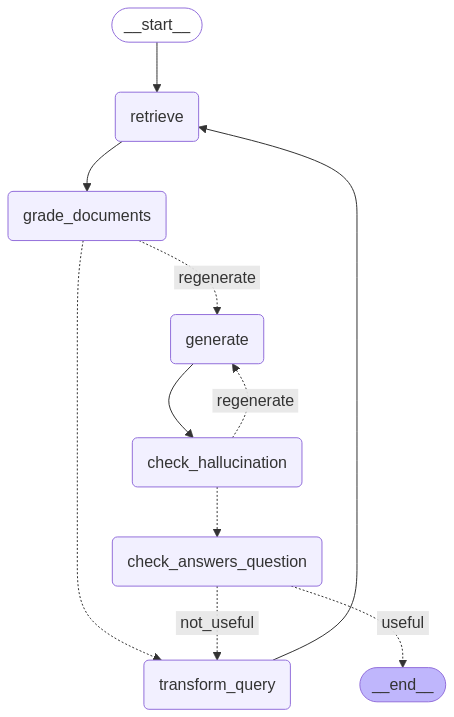

In [9]:
def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


self_rag_graph_builder = StateGraph(GraphState)

# Define the nodes
self_rag_graph_builder.add_node("retrieve", retrieve)  # retrieve
self_rag_graph_builder.add_node("grade_documents", grade_documents)  # grade documents
self_rag_graph_builder.add_node("generate", generate)  # generatae
self_rag_graph_builder.add_node("transform_query", transform_query)  # transform_query
self_rag_graph_builder.add_node(
    "check_hallucination", check_hallucination
)  # check hallucination
self_rag_graph_builder.add_node(
    "check_answers_question", check_answers_question
)  # check answers question

# Build graph
self_rag_graph_builder.add_edge(START, "retrieve")
self_rag_graph_builder.add_edge("retrieve", "grade_documents")
self_rag_graph_builder.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "regenerate": "generate",
    },
)
self_rag_graph_builder.add_edge("generate", "check_hallucination")
self_rag_graph_builder.add_edge("transform_query", "retrieve")
self_rag_graph_builder.add_conditional_edges(
    "check_hallucination",
    hallucination_router,
    {
        "check_answers_question": "check_answers_question",
        "regenerate": "generate",
    },
)
self_rag_graph_builder.add_conditional_edges(
    "check_answers_question",
    answer_quality_router,
    {
        "useful": END,
        "not_useful": "transform_query",
    },
)

# Compile
self_rag_graph = self_rag_graph_builder.compile()

# Visualize the graph
viz_graph(self_rag_graph)

In [10]:
# Run
if __name__ == "__main__":
    question = QUESTION_TEMPLATE.format(
        field="total_mineral_resource_tonnage",
        dtype="float",
        default=0,
        description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
    )
    inputs = {
        "question": question,
        "generation": "N/A",
        "retriever": create_markdown_retriever(
            "data/processed/43-101/0200a1c6d2cfafeb485d815d95966961d4c119e8662b8babec74e05b59ba4759d2.md",
            collection_name="rag-chroma",
        ),
        "hallucination_grade": "N/A",
        "hallucination_grader_reasoning": "N/A",
        "answer_grade": "N/A",
        "answer_grader_reasoning": "N/A",
    }

    value = self_rag_graph.invoke(inputs)

    # Final generation
    logger.info("---FINAL GENERATION---")
    logger.info(value["generation"])

2025-03-18 21:37:52.007 | INFO     | __main__:create_markdown_retriever:85 - Number of tokens: 49301
2025-03-18 21:37:52.007 | INFO     | __main__:create_markdown_retriever:86 - Number of splits: 56
2025-03-18 21:37:52.008 | INFO     | __main__:create_markdown_retriever:87 - Average tokens per split: 880
2025-03-18 21:37:53.835 | INFO     | __main__:retrieve:14 - ---RETRIEVE---
2025-03-18 21:37:54.122 | INFO     | __main__:grade_documents:75 - ---CHECK DOCUMENT RELEVANCE TO QUESTION---
2025-03-18 21:37:55.420 | INFO     | __main__:grade_documents:90 - ---GRADE: DOCUMENT NOT RELEVANT---
2025-03-18 21:37:56.582 | INFO     | __main__:grade_documents:87 - ---GRADE: DOCUMENT RELEVANT---
2025-03-18 21:37:58.155 | INFO     | __main__:grade_documents:87 - ---GRADE: DOCUMENT RELEVANT---
2025-03-18 21:37:59.526 | INFO     | __main__:grade_documents:90 - ---GRADE: DOCUMENT NOT RELEVANT---
2025-03-18 21:37:59.527 | INFO     | __main__:decide_to_generate:178 - ---ASSESS GRADED DOCUMENTS---
2025-03-